In [1]:
# Configuration and File Paths
import sys
import time
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import geopandas as gpd

from config import get_config, get_development_config, validate_config, setup_directories, print_config_summary
from src.simulation import simulate_asset_damage_recovery_access_optimized
from src.data_loader import load_hazard_maps, load_electricity_assets
from src.visualization import *
import src.grid_based_accessibility_hex as grid_hex

# #TODO: import and run sensitivity analysis


In [2]:
# Get configuration (currently from config.py)
# config = get_config()
config = get_development_config()

# Validate and setup
is_valid, missing_dirs = validate_config(config)
setup_directories(config)

# Print summary
print_config_summary(config)

# Handle validation results
if missing_dirs:
    print(f"\nWarning: Missing directories: {missing_dirs}")
else:
    print("\nAll data directories found successfully!")

# Set the hazard extraction method constant
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']
print(f"Hazard extraction method set to: {HAZARD_EXTRACTION_METHOD}")



Configuration Summary
Root directory: c:\repos\powerpath
Assets data: c:\repos\powerpath\data\test_samples\electricity
Hazard data: c:\repos\powerpath\data\test_samples\test_hazard_timesteps
Interim directory: c:\repos\powerpath\data\interim\interim_test_hazard_timesteps
Output directory: c:\repos\powerpath\data\output\output_test_hazard_timesteps

Simulation Configuration:
  number_repair_crews: 5
  repair_crew_assignment_method: islands
  flood_threshold: 0.2
  verbose: True
  accessibility_model: None

Recovery Parameters:
  repair_time_coefficients: [702.72, 3.14, 1.9891]
  damage_ratio_coefficients: (0.0468, 0.0077)
  time_step_hours: 1
  damage_threshold: 0.01
  repair_threshold: 2.0

Analysis Configuration:
  hazard_extraction_method: max
  max_simulation_days: 3
  cache_enabled: True
  performance_monitoring: True

All data directories found successfully!
Hazard extraction method set to: max


In [3]:
# Load data
print("Loading electricity assets...")
gdf_assets = load_electricity_assets(config['electricity_dir'], asset_types=['ls', 'msls'])

print("\nLoading hazard maps...")
hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=10)  
print("Data loading completed!")
print(f"\nHazard maps loaded:")
for i, hm in enumerate(hazard_maps):
    if i < 3:
        print(f"  -{hm}")
    elif i == 3:
        print(f"  and {len(hazard_maps) - 3} more")
        break




Loading electricity assets...
Found 2 electricity station files matching types ['ls', 'msls']
All .shp files in directory: ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Files with 'station': ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Final matched files: ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp']
Loading electricity assets from ls_stations_test_samples.shp
Loaded 36 ls assets
Loading electricity assets from msls_stations_test_samples.shp
Loaded 245 msls assets
Combined total: 281 electricity assets
Asset types: {'msls': 245, 'ls': 36}

Loading hazard maps...
Found 10 hazard map files
Data loading completed!

Hazard maps loaded:
  -c:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test0.tif
  -c:\repos\powerpath\data\test_samples\test_hazard_timesteps\GHG_timesteps_test1.tif
  -c:\repos\powerpath\data\test_samples\test_hazard_timeste

In [4]:
# Configure simulation parameters from config
simulation_params = {
    'flood_threshold': config['simulation_config']['flood_threshold'],
    'number_repair_crews': config['simulation_config']['number_repair_crews'],
    'repair_crew_assignment_method': config['simulation_config']['repair_crew_assignment_method'],
    'verbose': config['simulation_config']['verbose'],
    'damage_ratio_coefficients': config['recovery_parameters']['damage_ratio_coefficients'],
    'repair_time_coefficients': config['recovery_parameters']['repair_time_coefficients'],
    'damage_threshold': config['recovery_parameters']['damage_threshold'],
    'repair_threshold': config['recovery_parameters']['repair_threshold'],
    'config': config  # Pass entire config for directory management
}

accessibility_model = None#grid_hex.accessibility_model
simulation_params['accessibility_model'] = accessibility_model



print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")



Simulation configuration:
  flood_threshold: 0.2
  number_repair_crews: 5
  repair_crew_assignment_method: islands
  verbose: True
  damage_ratio_coefficients: (0.0468, 0.0077)
  repair_time_coefficients: [702.72, 3.14, 1.9891]
  damage_threshold: 0.01
  repair_threshold: 2.0
  accessibility_model: None

Directory structure:
  Interim: c:\repos\powerpath\data\interim\interim_test_hazard_timesteps
  Output: c:\repos\powerpath\data\output\output_test_hazard_timesteps
  Cache will be organized by hazard directory: test_hazard_timesteps


In [5]:
# simulation_params['verbose'] = False  # Set verbose to False for cleaner output

execution_id = int(time.time())
print(f"***Starting simulation execution {execution_id}***")

max_days = None#config['analysis_config']['max_simulation_days']

# Run the  simulation
results_df, final_state = simulate_asset_damage_recovery_access_optimized(
    gdf_assets=gdf_assets,
    hazard_maps=hazard_maps[:max_days],
    number_repair_crews=simulation_params['number_repair_crews'],
    repair_crew_assignment_method=simulation_params['repair_crew_assignment_method'],
    flood_threshold=simulation_params['flood_threshold'],
    recovery_parameters=config['recovery_parameters'],
    root_dir=config['root_dir'],
    verbose=simulation_params['verbose'], 
    timestep_output=True, 
    execution_id=execution_id,
    config=config
)

print(f"\n***Completed simulation execution {execution_id}***")

***Starting simulation execution 1755778735***
Using hazard directory for cache naming: test_hazard_timesteps

Loading optimization caches...
Loaded accessibility cache: 3 entries from c:\repos\powerpath\data\interim\accessibility_cache_test_hazard_timesteps.pkl
Loaded overlap cache: 2 entries from c:\repos\powerpath\data\interim\overlap_cache_test_hazard_timesteps.pkl
Loaded hazard extraction cache: 3 entries from c:\repos\powerpath\data\interim\cache\hazard_extraction_cache_test_hazard_timesteps.pkl
Loaded island cache: 3 entries from c:\repos\powerpath\data\interim\cache\island_cache_test_hazard_timesteps.pkl
Timestep output will be written to: c:\repos\powerpath\data\output\output_test_hazard_timesteps\timestep_output_1755778735.parquet
Island-based method 'islands' will be used for crew assignment

=== Processing timestep 0 (day 0) ===

Using cached hazard extraction for day 0 from GHG_timesteps_test0.tif
Using cached islands for 0.2_EV0_ma
Updating repair crew distribution for 1 

In [6]:
# Print text summary
print_simulation_summary(results_df, gdf_assets, config)

SIMULATION RESULTS SUMMARY
Total assets: 281
Simulation duration: 240 hours (10 days)
Final operational rate: 100.0%
Peak damaged assets: 11
Peak flooded assets: 11
Total crew assignments: 150

RECOVERY TIMELINE (Daily Summary)
Day 0: 100.0% operational, 0.0 flooded, 0.0 damaged
Day 1: 97.2% operational, 10.0 flooded, 10.0 damaged
Day 2: 96.8% operational, 11.0 flooded, 11.0 damaged
Day 3: 96.8% operational, 10.0 flooded, 11.0 damaged
Day 4: 97.9% operational, 7.0 flooded, 7.0 damaged
Day 5: 97.9% operational, 7.0 flooded, 7.0 damaged
Day 6: 98.9% operational, 0.0 flooded, 3.0 damaged
Day 7: 100.0% operational, 0.0 flooded, 0.0 damaged
Day 8: 100.0% operational, 0.0 flooded, 0.0 damaged
Day 9: 100.0% operational, 0.0 flooded, 0.0 damaged

REPAIR BACKLOG ANALYSIS
Hour | Flooded | Damaged | Crews | Backlog | Effective?
-------------------------------------------------------
 0.0 |     0.0 |     0.0 |   0.0 |     0.0 | No
24.0 |    10.0 |    10.0 |   0.0 |   144.9 | No
48.0 |    11.0 |   

In [7]:
results_df

,day,timestep,operational_count,accessible_count,flooded_count,damaged_count,crews_assigned_count,avg_damage_ratio,avg_repair_time,total_repair_backlog,total_damage_ratio
0,0,0,281,281,0,0,0,0.0,0.0,0.0,0.0
1,0,1,281,281,0,0,0,0.0,0.0,0.0,0.0
2,0,2,281,281,0,0,0,0.0,0.0,0.0,0.0
3,0,3,281,281,0,0,0,0.0,0.0,0.0,0.0
4,0,4,281,281,0,0,0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
235,9,235,281,281,0,0,0,0.0,0.0,0.0,0.0
236,9,236,281,281,0,0,0,0.0,0.0,0.0,0.0
237,9,237,281,281,0,0,0,0.0,0.0,0.0,0.0
238,9,238,281,281,0,0,0,0.0,0.0,0.0,0.0


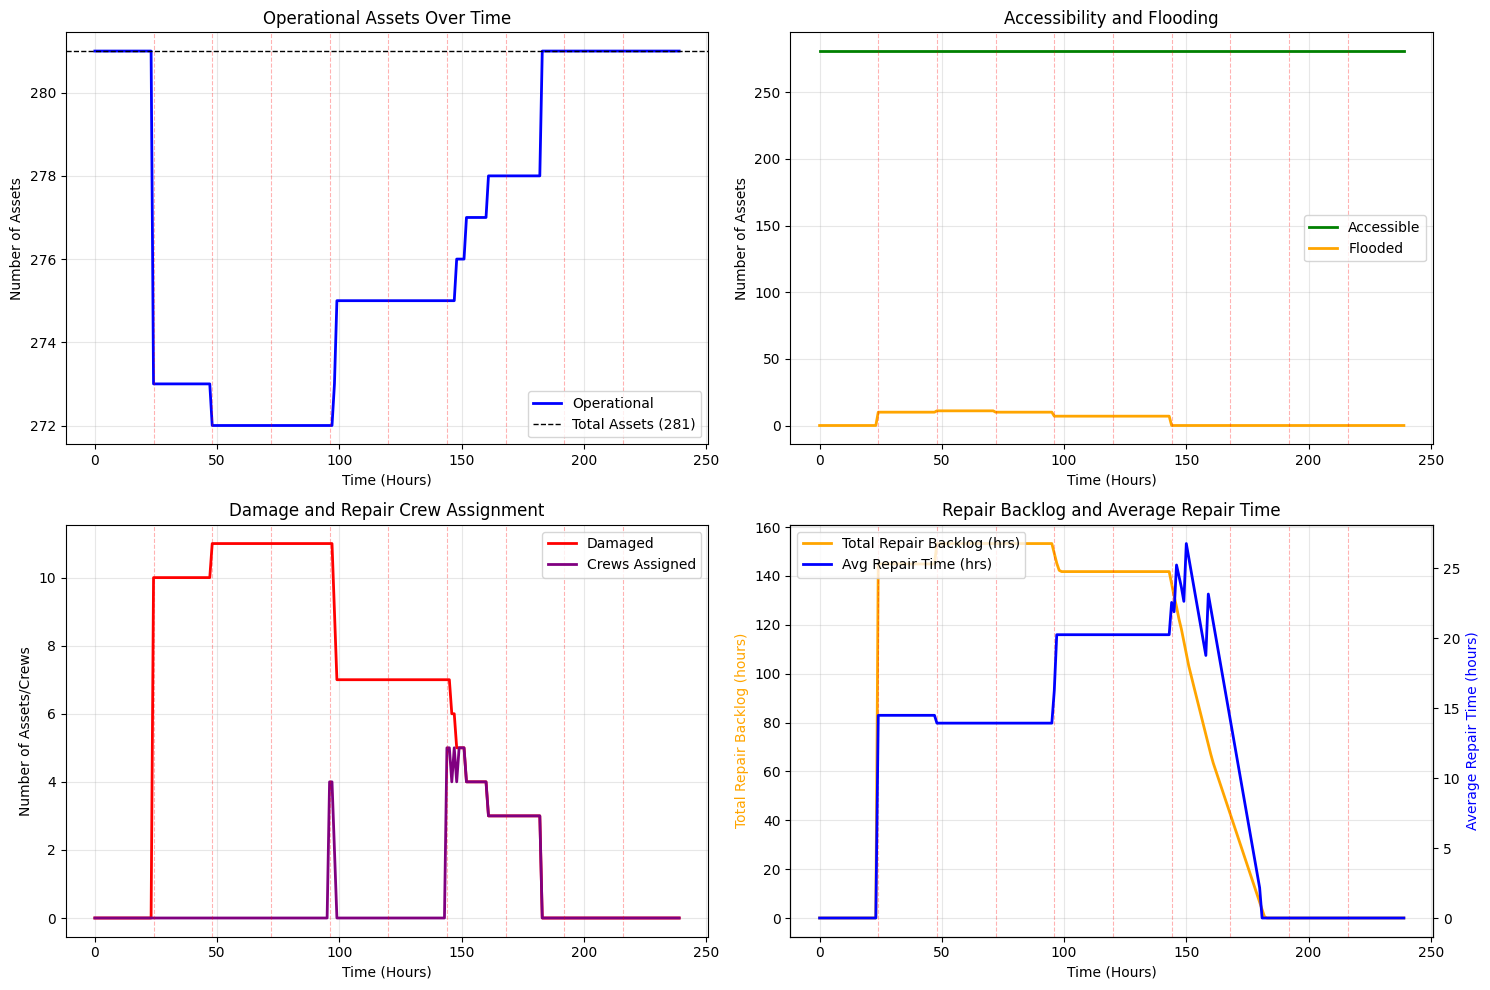

In [8]:
# Show summary plot
fig1 = plot_simulation_results_summary(results_df, gdf_assets, config)
plt.show()

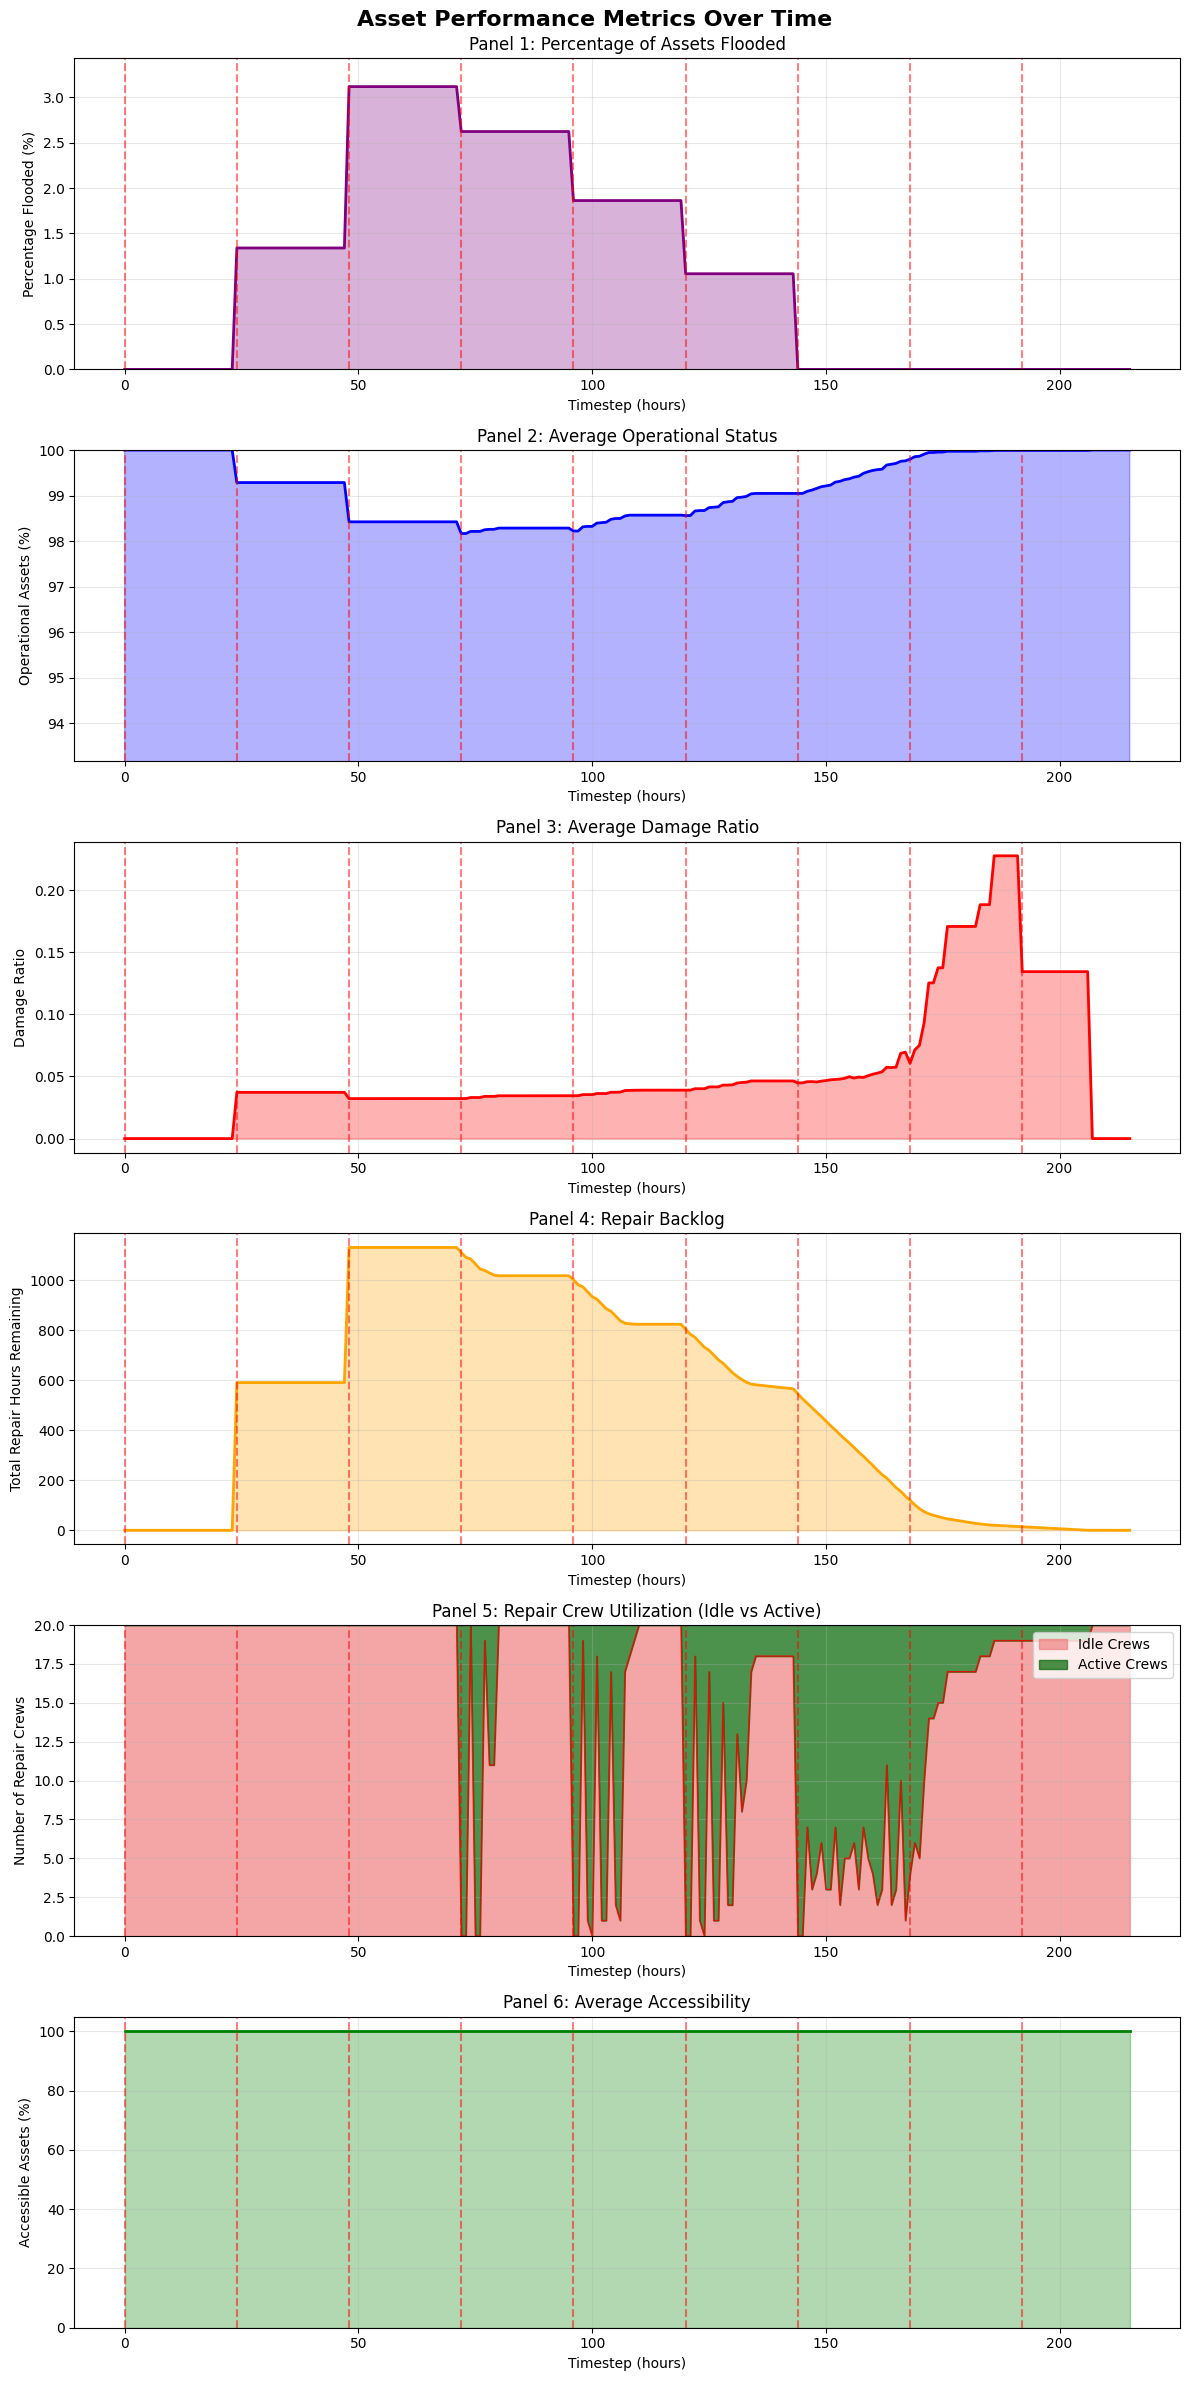

In [10]:
# Show detailed analysis
fig2 = plot_detailed_analysis_panels(results_df, gdf_assets, config)
plt.show()

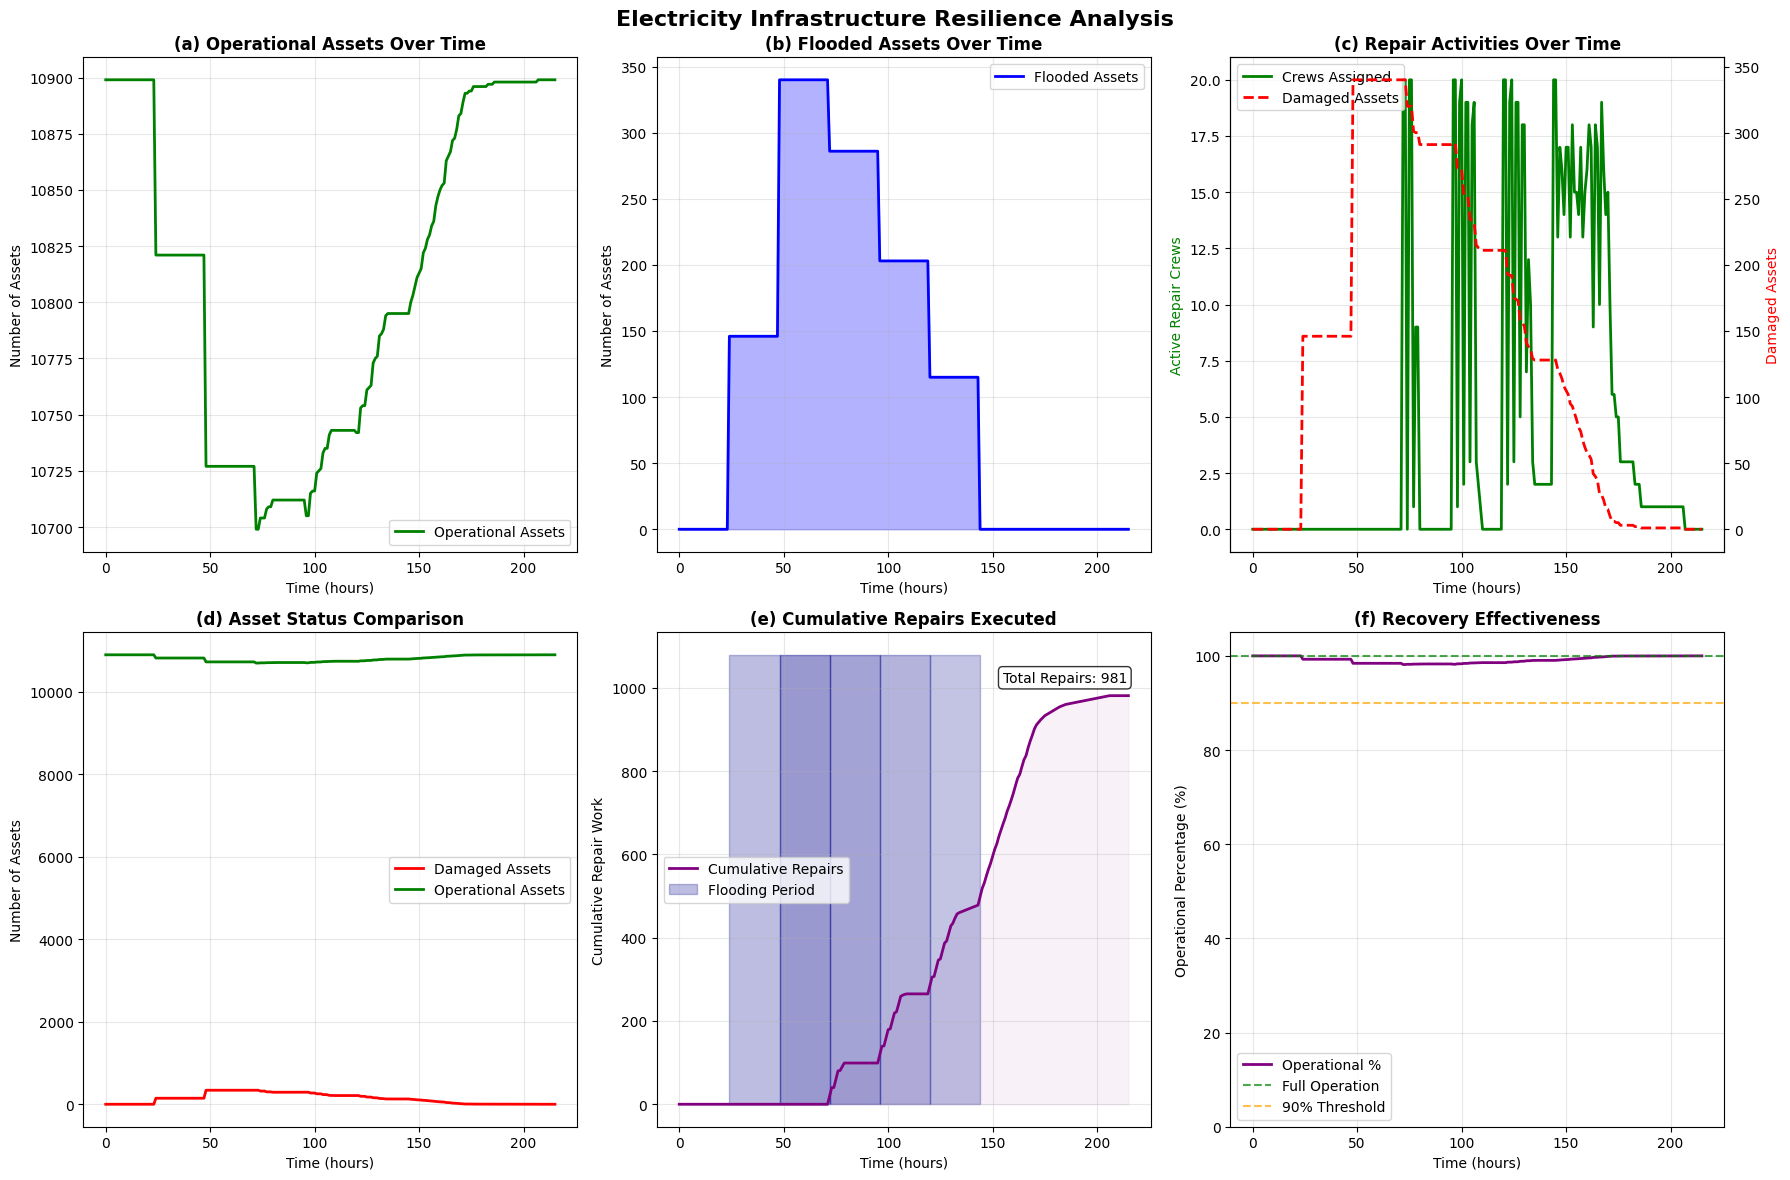

In [11]:
# Show comprehensive visualization
fig3 = create_comprehensive_visualization(results_df, gdf_assets, config)
plt.show()

In [12]:
# Save all visualizations
saved_files = save_all_visualizations(results_df, gdf_assets, config, config['output_dir'])

Saved 4 files to c:\repos\powerpath\data\output\output_hazard_maps_ZH_Delfland
   Combined PDF: all_visualizations_20250820_110559.pdf
   Individual PNGs: 3 files


In [13]:
# Load parquet file to map impacts
timesteps_df = pd.read_parquet(config['output_dir'] / f"timestep_output_{execution_id}.parquet")
timesteps_df.head(3)

,timestep,day,asset_id,damage_ratio,repair_time,operational,accessible,flooded,crew_assigned,hazard_value
0,0,0,0,0.0,0.0,1,1,0,0,0.0
1,0,0,1,0.0,0.0,1,1,0,0,0.0
2,0,0,2,0.0,0.0,1,1,0,0,0.0


In [14]:
# drop repeated columns for day and asset_id, only keep the first

timesteps_by_day = timesteps_df.drop_duplicates(subset=['day', 'asset_id'], keep='first')

geometries_list = []

for _,row in timesteps_by_day.iterrows():
    asset_id = row['asset_id']
    geom = gdf_assets.geometry[gdf_assets.index == asset_id].values[0]
    geometries_list.append(geom)

timesteps_by_day_gdf = gpd.GeoDataFrame(timesteps_by_day, geometry=geometries_list)
timesteps_by_day_gdf.tail(3)

path_export = config['output_dir'] / 'timesteps_by_day_gdf.gpkg'
#r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\misc_data\timesteps_by_day_gdf.gpkg'

timesteps_by_day_gdf.to_file(path_export, driver='GPKG')

In [15]:
# Population
import geopandas as gpd
root_dir = config['root_dir']
population_data_path = root_dir / "data" / "population" / "cbs_vk100_2024_v1.gpkg"
assert population_data_path.exists()


In [18]:
### To do make paths etc. flexible
# study_area_path = root_dir /'data'/ 'static' /'network'/ 'try_study_area_larger.shp'
study_area_path = root_dir / 'raw_data' / 'ZH_Delfland_2' / 'static' / 'network' / 'extent.shp'
study_area = gpd.read_file(study_area_path, driver='ESRI Shapefile').to_crs("EPSG:28992")


In [19]:
buffer_distance_meters = 1000
population_buffer = study_area.buffer(buffer_distance_meters)
population_buffer.set_crs("EPSG:28992")


0    POLYGON ((96904.022 433624.151, 96898.028 4335...
dtype: geometry

In [20]:

import geopandas as gpd

# Get the bounds of your study area first
study_area_bounds = population_buffer.bounds
minx, miny, maxx, maxy = study_area_bounds.iloc[0]

# Use bbox parameter to load only relevant data
population_data = gpd.read_file(
    population_data_path, 
    driver='GPKG',
    bbox=(minx, miny, maxx, maxy)  # Only load data within bounding box
).to_crs("EPSG:28992")

# Filter out zero population and invalid geometries early
population_data = population_data[
    (population_data['aantal_inwoners'] > 0) & 
    (~population_data.geometry.isna())
].dropna(subset=['geometry'])

# Now clip to your exact study area
population_study_area = gpd.clip(population_data, population_buffer)

# Clean up
del population_data

# make a new gdf only keeping the aantal inwoners column and the geometries
population_above_0 = population_study_area[['aantal_inwoners', 'geometry']].set_crs("EPSG:28992")

In [21]:
def create_voronoi_for_asset_type(gdf_assets, asset_type, bounding_box):
    """Create Voronoi polygons for a specific asset type"""
    from scipy.spatial import Voronoi
    from shapely.geometry import Polygon
    import geopandas as gpd
    
    # Filter assets by type and get centroids
    assets_filtered = gdf_assets[gdf_assets['type'] == asset_type].copy()
    assets_filtered['geometry'] = assets_filtered['geometry'].to_crs("EPSG:28992").centroid
    
    # Create Voronoi polygons with asset IDs
    points = assets_filtered.geometry.apply(lambda geom: (geom.x, geom.y)).tolist()
    asset_ids = assets_filtered.index.tolist()
    
    vor = Voronoi(points)
    polygons = []
    valid_asset_ids = []
    
    for point_idx, region_idx in enumerate(vor.point_region):
        region = vor.regions[region_idx]
        if not -1 in region and len(region) > 0:
            polygon = Polygon([vor.vertices[i] for i in region])
            clipped_polygon = polygon.intersection(bounding_box)
            
            if not clipped_polygon.is_empty and clipped_polygon.is_valid:
                polygons.append(clipped_polygon)
                valid_asset_ids.append(asset_ids[point_idx])
    
    voronoi_gdf = gpd.GeoDataFrame(geometry=polygons)
    voronoi_gdf = voronoi_gdf.set_crs(assets_filtered.crs)
    voronoi_gdf['asset_id'] = valid_asset_ids
    
    return voronoi_gdf

def assign_impact_metric_to_voronoi(voronoi_gdf, impact_data, impact_column='aantal_inwoners'):
    """
    Assign impact metric to Voronoi polygons using area-weighted intersection
    
    Parameters:
    -----------
    voronoi_gdf : GeoDataFrame
        Voronoi polygons with asset_id column
    impact_data : GeoDataFrame
        Impact data (e.g., population, economic value, etc.)
    impact_column : str
        Column name containing the impact metric values
    
    Returns:
    --------
    GeoDataFrame : Voronoi polygons with assigned_impact_metric column
    """
    import geopandas as gpd
    
    voronoi = voronoi_gdf.copy()
    impact_grid = impact_data.copy()
    
    # Ensure CRS match
    impact_grid = impact_grid.to_crs(voronoi.crs)
    
    # Calculate area of each impact grid cell
    impact_grid["cell_area"] = impact_grid.geometry.area
    
    # Preserve Voronoi index before overlay
    voronoi["voronoi_index"] = voronoi.index
    
    # Spatial intersection
    intersections = gpd.overlay(impact_grid, voronoi, how="intersection")
    
    # Calculate area of intersection
    intersections["intersect_area"] = intersections.geometry.area
    
    # Area-weighted impact metric
    intersections["weighted_impact_metric"] = (
        intersections[impact_column] * intersections["intersect_area"] / intersections["cell_area"]
    )
    
    # Aggregate impact metric by Voronoi index
    impact_by_voronoi = (
        intersections.groupby("voronoi_index")["weighted_impact_metric"].sum().reset_index()
    )
    
    # Merge back to Voronoi polygons
    voronoi = voronoi.merge(impact_by_voronoi, on="voronoi_index", how="left")
    voronoi = voronoi.rename(columns={"weighted_impact_metric": "assigned_impact_metric"})
    voronoi['assigned_impact_metric'] = voronoi['assigned_impact_metric'].fillna(0)
    
    return voronoi

def filter_timesteps_by_asset_type(gdf_assets, timesteps_df, asset_type):
    """Filter timesteps DataFrame by asset type"""
    gdf_assets_filt = gdf_assets[gdf_assets['type'] == asset_type]
    timesteps_df_filt = timesteps_df[timesteps_df['asset_id'].isin(gdf_assets_filt.index)]
    return timesteps_df_filt

def calculate_affected_impact_by_timestep(timesteps_df, voronoi_gdf, impact_metric_column='assigned_impact_metric'):
    """
    Calculate affected impact metric for each asset at each timestep
    
    Parameters:
    -----------
    timesteps_df : DataFrame
        Timestep data with operational status
    voronoi_gdf : GeoDataFrame
        Voronoi polygons with impact metric assignments
    impact_metric_column : str
        Column name containing the impact metric values
        
    Returns:
    --------
    dict : Nested dictionary {asset_id: {timestep: affected_impact}}
    """
    import pandas as pd
    
    # Create mapping from asset_id to impact metric
    impact_by_asset = dict(zip(voronoi_gdf['asset_id'], voronoi_gdf[impact_metric_column]))
    
    # Add impact metric data to timesteps_df
    timesteps_df = timesteps_df.copy()
    timesteps_df['impact_metric'] = timesteps_df['asset_id'].map(impact_by_asset)
    
    # Calculate affected impact metric: (1-operational) * impact_metric
    timesteps_df['affected_impact'] = (1 - timesteps_df['operational']) * timesteps_df['impact_metric']
    
    # Group by asset_id and timestep, then convert to nested dict
    grouped = timesteps_df.groupby(['asset_id', 'timestep'])['affected_impact'].first()
    
    # Convert to nested dictionary structure
    impact_by_asset_ts = {}
    for (asset_id, timestep), affected_impact in grouped.items():
        if asset_id not in impact_by_asset_ts:
            impact_by_asset_ts[asset_id] = {}
        impact_by_asset_ts[asset_id][timestep] = affected_impact
    
    return impact_by_asset_ts

def find_most_impactful_assets(impact_affected_dict, top_percent=None, min_impact=0):
    """
    Identify most impactful assets based on total impact
    
    Parameters:
    -----------
    impact_affected_dict : dict
        Nested dictionary with impact data by asset and timestep
    top_percent : float, optional
        Percentage of top impactful assets to select (e.g., 0.05 for 5%)
    min_impact : float
        Minimum impact threshold for selection
        
    Returns:
    --------
    tuple : (selected_asset_ids, detailed_impact_dict, all_asset_impacts)
    """
    import pandas as pd
    
    # Calculate total impact per asset across all timesteps
    asset_total_impacts = {}
    for asset_id, timestep_data in impact_affected_dict.items():
        total_impact = sum(impact for impact in timestep_data.values() if not pd.isna(impact))
        asset_total_impacts[asset_id] = total_impact
    
    # Sort assets by total impact (descending)
    sorted_assets = sorted(asset_total_impacts.items(), key=lambda x: x[1], reverse=True)
    
    # Select assets based on criteria
    if top_percent:
        count = max(1, int(len(sorted_assets) * top_percent))
        selected_assets = [asset_id for asset_id, impact in sorted_assets[:count] if impact > 0]
    else:
        # Select all assets with impact > min_impact
        selected_assets = [asset_id for asset_id, impact in sorted_assets if impact > min_impact]
    
    # Create detailed impact dictionary
    mia = {
        asset: {
            'total_impact': asset_total_impacts[asset],
            'timestep_data': impact_affected_dict[asset]
        } 
        for asset in selected_assets
    }
    
    return selected_assets, mia, asset_total_impacts

def prepare_visualization_data(asset_ids, gdf_assets, voronoi_gdf, mia_dict, timesteps_df, 
                              impact_metric_column='assigned_impact_metric'):
    """
    Prepare data for visualization (sizes, colors, impact metrics, etc.)
    
    Parameters:
    -----------
    asset_ids : list
        List of selected asset IDs
    gdf_assets : GeoDataFrame
        Assets geodataframe
    voronoi_gdf : GeoDataFrame
        Voronoi polygons with impact metric
    mia_dict : dict
        Most impactful assets dictionary
    timesteps_df : DataFrame
        Timestep data
    impact_metric_column : str
        Column name for the impact metric
        
    Returns:
    --------
    dict : Dataset dictionary ready for visualization
    """
    import pandas as pd
    
    # Get GeoDataFrame for selected assets
    selected_gdf = gdf_assets[gdf_assets.index.isin(asset_ids)]
    
    # Calculate visualization data
    total_impacts = []
    asset_impact_metrics = []

    raw_population_by_asset = {}
    
    for asset_id in selected_gdf.index:
        # Get total impact for color
        total_impacts.append(mia_dict[asset_id]['total_impact'])
        
        # Get impact metric for size from voronoi data
        matching_voronoi = voronoi_gdf[voronoi_gdf['asset_id'] == asset_id]
        print(matching_voronoi.columns)
        if len(matching_voronoi) > 0:
            asset_impact_metrics.append(matching_voronoi[impact_metric_column].iloc[0])
            # raw_population_by_asset[asset_id] = matching_voronoi['aantal_inwoners'].iloc[0]
        else:
            asset_impact_metrics.append(0)
            raw_population_by_asset[asset_id] = 0

    # Normalize sizes based on impact metric (scale between 10-210 for visibility)
    if max(asset_impact_metrics) > 0:
        max_metric = max(asset_impact_metrics)
        normalized_sizes = [metric / max_metric * 200 + 10 for metric in asset_impact_metrics]
    else:
        normalized_sizes = [200] * len(asset_impact_metrics)
    
    # Calculate summary statistics
    sum_by_timestep = {}
    timesteps_filtered = timesteps_df[timesteps_df['asset_id'].isin(asset_ids)]
    
    for timestep in timesteps_filtered['timestep'].unique():
        total_affected = 0
        for asset_id in voronoi_gdf['asset_id']:
            if asset_id in mia_dict:
                impact_value = mia_dict[asset_id]['timestep_data'].get(timestep, 0)
                if not pd.isna(impact_value):
                    total_affected += impact_value
        sum_by_timestep[timestep] = total_affected
    
    worst_timestep = max(sum_by_timestep.keys(), key=lambda x: sum_by_timestep[x]) if sum_by_timestep else 0
    worst_impact = sum_by_timestep.get(worst_timestep, 0)
    
    return {
        'gdf': selected_gdf,
        'voronoi': voronoi_gdf,
        'sizes': normalized_sizes,
        'impacts': total_impacts,
        'impact_metrics': asset_impact_metrics,  # Generic term instead of 'populations'
        # 'raw_population_by_asset': raw_population_by_asset,
        'mia': mia_dict,
        'worst_timestep': worst_timestep,
        'worst_impact': worst_impact,
        'centroids': selected_gdf.to_crs(epsg=3857).centroid
    }

def analyze_asset_impact_metric(asset_types, gdf_assets, timesteps_df, impact_data, bounding_box, 
                               impact_column='aantal_inwoners', top_percent=0.05, verbose=False):
    """
    Main orchestration function that analyzes impact metrics for multiple asset types
    
    Parameters:
    -----------
    asset_types : list
        List of asset type strings (e.g., ['msls', 'ls'])
    gdf_assets : GeoDataFrame
        Assets geodataframe
    timesteps_df : DataFrame  
        Timestep simulation results
    impact_data : GeoDataFrame
        Impact metric data (population, economic value, etc.)
    bounding_box : Polygon
        Study area bounding box
    impact_column : str
        Column name containing the impact metric values
    top_percent : float
        Percentage of top impactful assets to select (default 0.05 = 5%)
    verbose : bool
        Verbose output for debugging

    Returns:
    --------
    dict : Dictionary with asset_type as keys and dataset dictionaries as values
    """
    results = {}
    
    for asset_type in asset_types:
        print(f"\nProcessing {asset_type.upper()} assets...")
        
        # Create Voronoi polygons
        voronoi_gdf = create_voronoi_for_asset_type(gdf_assets, asset_type, bounding_box)
        if verbose:
            print(f"  Created {len(voronoi_gdf)} Voronoi polygons")

        # Assign impact metric to Voronoi polygons
        voronoi_with_impact = assign_impact_metric_to_voronoi(voronoi_gdf, impact_data, impact_column)
        if verbose:
            print(f"  Assigned impact metric to Voronoi polygons")

        # Filter timesteps for this asset type
        timesteps_filtered = filter_timesteps_by_asset_type(gdf_assets, timesteps_df, asset_type)
        if verbose:
            print(f"  Filtered to {len(timesteps_filtered)} timestep records")

        # Calculate affected impact metric by timestep
        impact_affected = calculate_affected_impact_by_timestep(timesteps_filtered, voronoi_with_impact)
        
        # Find most impactful assets
        impactful_assets, mia_dict, all_impacts = find_most_impactful_assets(
            impact_affected, top_percent=top_percent
        )
        if verbose:
            print(f"  Found {len(impactful_assets)} most impactful assets")

        # Prepare dataset for visualization
        dataset = prepare_visualization_data(
            impactful_assets, gdf_assets, voronoi_with_impact, mia_dict, timesteps_filtered
        )
        
        # Add asset type identifier
        dataset['asset_type'] = asset_type.upper()
        
        results[asset_type] = dataset
        
        print(f"  Total impact: {sum(dataset['impacts']):.1f} impact-hours")
    
    return results

In [33]:
def create_combined_type_plot(datasets, figsize=(18, 14), padding=3000, 
                             title_suffix="", edge_linewidth=1.0, impact_unit="people", tags=True):
    """
    Create a combined plot showing most impactful assets from multiple asset types.
    Fixed legend shows standard reference values: 100, 500, 1000.
    """
    import matplotlib.pyplot as plt
    import contextily as ctx
    import numpy as np
    from matplotlib.lines import Line2D
    
    # Default configurations for common asset types
    default_configs = {
        'msls': {
            'edge_color': 'red',
            'label_color': 'lightsalmon', 
            'cmap': 'Reds',
            'label_prefix': 'M',
            'asset_type': 'MSLS'
        },
        'ls': {
            'edge_color': 'blue',
            'label_color': 'lightblue',
            'cmap': 'Blues', 
            'label_prefix': 'L',
            'asset_type': 'LS'
        },
        'c2000': {
            'edge_color': 'green',
            'label_color': 'lightgreen',
            'cmap': 'Greens',
            'label_prefix': 'C',
            'asset_type': 'C2000'
        }
    }
    
    if not datasets:
        print("No datasets provided!")
        return None, None
    
    print(f"Creating combined visualization of {len(datasets)} asset types")
    
    # Apply defaults for missing attributes
    processed_datasets = []
    for i, dataset in enumerate(datasets):
        dataset = dataset.copy()  # Don't modify original
        
        # Try to infer asset type from data if not provided
        asset_type_key = dataset.get('asset_type', f'type_{i+1}')
        
        # Get defaults based on asset type or use generic defaults
        if isinstance(asset_type_key, str) and asset_type_key.lower() in default_configs:
            defaults = default_configs[asset_type_key.lower()]
        else:
            # Generic defaults
            colors = ['red', 'blue', 'green', 'orange', 'purple']
            cmaps = ['Reds', 'Blues', 'Greens', 'Oranges', 'Purples']
            defaults = {
                'edge_color': colors[i % len(colors)],
                'label_color': f'light{colors[i % len(colors)]}' if colors[i % len(colors)] != 'red' else 'yellow',
                'cmap': cmaps[i % len(cmaps)],
                'label_prefix': str(i+1),
                'asset_type': f'Type {i+1}'
            }
        
        # Apply defaults for missing keys
        for key, default_value in defaults.items():
            if key not in dataset:
                dataset[key] = default_value
        
        # Ensure centroids are in Web Mercator
        if 'centroids' not in dataset:
            dataset['centroids'] = dataset['gdf'].to_crs(epsg=3857).centroid
        elif hasattr(dataset['centroids'], 'crs') and dataset['centroids'].crs != 'EPSG:3857':
            dataset['centroids'] = dataset['centroids'].to_crs(epsg=3857)
        
        processed_datasets.append(dataset)
    
    # Collect all impact metrics from all datasets
    all_impact_metrics = []
    for dataset in processed_datasets:
        all_impact_metrics.extend(dataset['impact_metrics'])
    
    # Find the global maximum impact metric across all asset types
    if len(all_impact_metrics) > 0 and max(all_impact_metrics) > 0:
        global_max_metric = max(all_impact_metrics)
        print(f"  Global max impact metric: {global_max_metric:.1f} {impact_unit}")
        
        # Recalculate sizes for each dataset using the global maximum
        for dataset in processed_datasets:
            # Normalize sizes based on global maximum (consistent across asset types)
            normalized_sizes = []
            for metric in dataset['impact_metrics']:
                if global_max_metric > 0:
                    size = metric / global_max_metric * 200 + 10  # Scale 10-210
                else:
                    size = 50  # Default size
                normalized_sizes.append(size)
            
            # Update the dataset with consistent sizes
            dataset['sizes'] = normalized_sizes
    else:
        # Fallback if no impact metrics
        global_max_metric = 1000  # Default for legend calculation
        for dataset in processed_datasets:
            dataset['sizes'] = [100] * len(dataset['impact_metrics'])
    
    # Calculate combined bounds for all asset types
    all_bounds = []
    for dataset in processed_datasets:
        bounds = dataset['gdf'].to_crs(epsg=3857).total_bounds
        all_bounds.append(bounds)
    
    # Calculate overall bounds
    combined_bounds = [
        min(bounds[0] for bounds in all_bounds),  # min x
        min(bounds[1] for bounds in all_bounds),  # min y
        max(bounds[2] for bounds in all_bounds),  # max x
        max(bounds[3] for bounds in all_bounds)   # max y
    ]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Add padding to bounds
    plot_bounds_combined = [
        combined_bounds[0] - padding,
        combined_bounds[1] - padding,
        combined_bounds[2] + padding,
        combined_bounds[3] + padding
    ]
    
    # Set axis limits
    ax.set_xlim(plot_bounds_combined[0], plot_bounds_combined[2])
    ax.set_ylim(plot_bounds_combined[1], plot_bounds_combined[3])
    
    # Add OSM basemap
    ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.CartoDB.Positron, 
                    alpha=0.9, zorder=1)
    
    # Plot all Voronoi boundaries and highlights
    for dataset in processed_datasets:
        voronoi_plot = dataset['voronoi'].copy().to_crs(epsg=3857)
        
        # All boundaries (light)
        voronoi_plot.boundary.plot(ax=ax, color=dataset['label_color'], linewidth=0.4, zorder=2, alpha=0.15)

        # Highlighted boundaries for most impactful assets
        most_impactful_asset_ids = dataset['gdf'].index.tolist()
        voronoi_highlight = voronoi_plot[voronoi_plot['asset_id'].isin(most_impactful_asset_ids)]
        voronoi_highlight.boundary.plot(ax=ax, color=dataset['edge_color'], 
                                       linewidth=1.5, zorder=3, alpha=0.7)
    
    # Plot assets and collect scatter objects for colorbars
    scatter_objects = []
    legend_elements = []
    unique_cmaps = []
    
    # Store all label information for smart positioning
    all_labels = []
    
    for dataset in processed_datasets:
        # Plot assets with consistent sizes
        scatter = ax.scatter(
            dataset['centroids'].x, 
            dataset['centroids'].y,
            s=dataset['sizes'],  # Now using globally normalized sizes
            c=dataset['impacts'],
            # c=dataset['impact_metrics'],  # Using impact metrics for color     
            cmap=dataset['cmap'],
            alpha=0.9,
            edgecolors=dataset['edge_color'],
            linewidth=edge_linewidth,
            zorder=6,
            label=f"{dataset['asset_type']} Assets"
        )
        scatter_objects.append(scatter)
        
        # Track unique colormaps for multiple colorbars
        if dataset['cmap'] not in unique_cmaps:
            unique_cmaps.append(dataset['cmap'])
        
        # Add to legend elements
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                   markersize=8, label=f"{dataset['asset_type']} Assets", 
                   markeredgecolor=dataset['edge_color'], markeredgewidth=2)
        )
        
        # Collect label information for smart positioning
        if tags:
            for asset_id in dataset['gdf'].index:
                point = dataset['centroids'][dataset['centroids'].index == asset_id].iloc[0]
                impact_k = dataset['mia'][asset_id]["total_impact"] / 1000
                label_info = {
                    'x': point.x,
                    'y': point.y,
                    'text': f'{dataset["label_prefix"]}{asset_id}\n{impact_k:.1f}k',
                    'facecolor': dataset['label_color'],
                    'edgecolor': dataset['edge_color']
                }
                all_labels.append(label_info)
    
    # Smart label positioning to avoid overlaps, only if tags is True
    if tags:
        positioned_labels = position_labels_smart(all_labels, ax, plot_bounds_combined)
        # Add positioned labels
        for label_info in positioned_labels:
            ax.annotate(
                label_info['text'], 
                (label_info['x'], label_info['y']),
                xytext=(label_info['offset_x'], label_info['offset_y']), 
                textcoords='offset points',
                fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=label_info['facecolor'], 
                         alpha=0.9, edgecolor=label_info['edgecolor'], linewidth=1),
                zorder=7,
                ha='center',
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.6, lw=0.8) if label_info.get('needs_arrow', False) else None
            )
    
    # Add asset type legend
    type_legend = ax.legend(handles=legend_elements, 
                           title='Asset Types\n(Edge Color)', 
                           loc='upper right', 
                           bbox_to_anchor=(0.98, 0.98),
                           frameon=True, 
                           fancybox=True, 
                           shadow=True,
                           title_fontsize=11,
                           fontsize=10)
    type_legend.get_frame().set_facecolor('white')
    type_legend.get_frame().set_alpha(0.9)
    
    if global_max_metric > 0:
        # Always use these standard reference values
        standard_metric_values = [100, 500, 1000]
        
        legend_elements_size = []
        for metric_val in standard_metric_values:
            # Calculate size using the same formula as actual data points
            size_val = metric_val / global_max_metric * 600
            
            legend_elements_size.append(
                Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                        markersize=np.sqrt(size_val/4), label=f'{int(metric_val):,} {impact_unit}',
                        markeredgecolor='black', markeredgewidth=1)
            )
        
        # Add actual maximum if it's significantly different from 1000
        if global_max_metric > 1.2 * standard_metric_values[-1]:  # Only add if max is significantly larger than 1000
            max_size_val = global_max_metric / global_max_metric * 600  # Will be 210
            legend_elements_size.append(
                Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                       markersize=np.sqrt(max_size_val/4), label=f'{int(global_max_metric):,} {impact_unit}',
                       markeredgecolor='black', markeredgewidth=1)
            )
        
        if legend_elements_size:  # Only create legend if we have elements
            size_legend = ax.legend(handles=legend_elements_size, 
                                   title=f'Population Served\n(Circle Size)', 
                                   loc='upper left', 
                                   bbox_to_anchor=(0.02, 0.98),
                                   frameon=True, 
                                   fancybox=True, 
                                   shadow=True,
                                   title_fontsize=11,
                                   fontsize=10)
            size_legend.get_frame().set_facecolor('white')
            size_legend.get_frame().set_alpha(0.9)
            ax.add_artist(type_legend)
    
    # Add multiple colorbars if different colormaps are used
    if len(unique_cmaps) > 1:
        # Multiple colorbars for different asset types
        colorbar_positions = [0.02, 0.04, 0.06]  # Different pad values
        for i, (scatter, dataset) in enumerate(zip(scatter_objects, processed_datasets)):
            if i < len(colorbar_positions):
                cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, 
                                   pad=colorbar_positions[i], aspect=30)
                # cbar.set_label(f'{dataset["asset_type"]} Impact ({impact_unit})', 
                cbar.set_label(f'{dataset["asset_type"]} Impact ({impact_unit}-hours)', 
                              fontsize=10, rotation=270, labelpad=20)
    else:
        # Single colorbar if all use same colormap
        asset_cbar = plt.colorbar(scatter_objects[0], ax=ax, shrink=0.6, pad=0.02)
        asset_cbar.set_label(f'Asset Impact ({impact_unit}-hours)', fontsize=12)
    
    # Calculate combined statistics
    worst_timestep_combined = max(dataset['worst_timestep'] for dataset in processed_datasets)
    total_impact_combined = sum(dataset['worst_impact'] for dataset in processed_datasets)
    total_assets = sum(len(dataset['gdf']) for dataset in processed_datasets)
    
    # Create title (generic)
    asset_type_names = " & ".join([f"{d['asset_type']} ({d['edge_color'].title()} Edges)" 
                                  for d in processed_datasets])
    
    ax.set_title(f'Most Impactful Electricity Assets - Combined View{title_suffix}\n'
                 f'{asset_type_names} - Peak Impact at Timestep {worst_timestep_combined}\n'
                 f'Total Impact Affected: {total_impact_combined:.0f} {impact_unit} '
                 f'({total_assets} assets)\n'
                 f'Size = Impact Metric Served, Color = Impact Severity', 
                 fontsize=14, fontweight='bold', pad=25)
    
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()
    
    # Print combined summary (generic)
    print(f"\nCombined Asset Summary:")
    total_combined_impact = 0
    for dataset in processed_datasets:
        asset_count = len(dataset['gdf'])
        total_impact = sum(dataset['impacts'])
        total_combined_impact += total_impact
        print(f"  {dataset['asset_type']} Assets: {asset_count} assets, "
              f"Total Impact: {total_impact:.1f} {impact_unit}-hours")
    print(f"  Combined Total Impact: {total_combined_impact:.1f} {impact_unit}-hours")
    
    return fig, ax

def position_labels_smart(labels, ax, plot_bounds, min_distance=800):
    """
    Smart label positioning algorithm to avoid overlaps
    """
    import numpy as np
    from scipy.spatial.distance import pdist, squareform
    
    positioned_labels = []
    
    if not labels:
        return positioned_labels
    
    # Extract coordinates
    coords = np.array([[label['x'], label['y']] for label in labels])
    
    # Calculate pairwise distances
    distances = squareform(pdist(coords))
    
    # Define possible offset positions (in offset points)
    offset_positions = [
        (20, 20), (20, -20), (-20, 20), (-20, -20),
        (30, 0), (-30, 0), (0, 30), (0, -30),
        (35, 15), (35, -15), (-35, 15), (-35, -15)
    ]
    
    for i, label in enumerate(labels):
        best_offset = (15, 15)  # Default offset
        needs_arrow = False
        
        # Check if this label is too close to others
        close_labels = []
        for j, other_label in enumerate(labels):
            if i != j and distances[i, j] < min_distance:
                close_labels.append(j)
        
        if close_labels:
            # Try different offset positions to minimize conflicts
            best_score = float('inf')
            
            for offset in offset_positions:
                # Convert offset points to map coordinates for conflict checking
                offset_map_x = offset[0] * 35
                offset_map_y = offset[1] * 35
                
                label_pos_x = label['x'] + offset_map_x
                label_pos_y = label['y'] + offset_map_y
                
                # Check conflicts with other labels
                conflicts = 0
                for j in close_labels:
                    other_x = labels[j]['x']
                    other_y = labels[j]['y']
                    
                    # Estimate other label position
                    if j < i:  # Already positioned
                        other_label_x = positioned_labels[j]['x'] + positioned_labels[j]['offset_x'] * 35
                        other_label_y = positioned_labels[j]['y'] + positioned_labels[j]['offset_y'] * 35
                    else:
                        other_label_x = other_x + 15 * 35  # Default offset
                        other_label_y = other_y + 15 * 35
                    
                    # Check distance between label positions
                    label_distance = np.sqrt((label_pos_x - other_label_x)**2 + (label_pos_y - other_label_y)**2)
                    
                    if label_distance < min_distance * 0.8:  # Label area conflict
                        conflicts += 1
                
                # Penalize positions that go outside plot bounds
                if (label_pos_x < plot_bounds[0] + min_distance or 
                    label_pos_x > plot_bounds[2] - min_distance or
                    label_pos_y < plot_bounds[1] + min_distance or 
                    label_pos_y > plot_bounds[3] - min_distance):
                    conflicts += 2
                
                if conflicts < best_score:
                    best_score = conflicts
                    best_offset = offset
            
            # If we had to move the label significantly, add an arrow
            if abs(best_offset[0]) > 25 or abs(best_offset[1]) > 25:
                needs_arrow = True
        
        # Create positioned label
        positioned_label = label.copy()
        positioned_label['offset_x'] = best_offset[0]
        positioned_label['offset_y'] = best_offset[1]
        positioned_label['needs_arrow'] = needs_arrow
        
        positioned_labels.append(positioned_label)
    
    return positioned_labels

In [28]:
from shapely.geometry import box

bbox_pop = box(*population_buffer.total_bounds)

# Call impact analysis function using voronoi polygons and grided impact metric
results = analyze_asset_impact_metric(
    asset_types=['msls', 'ls'],
    gdf_assets=gdf_assets,
    timesteps_df=timesteps_df,
    impact_data=population_above_0,  # Can be any impact metric data
    bounding_box=bbox_pop,
    impact_column='aantal_inwoners',  # column name of the impact metric, in the case of population, grid cell population is in 'aantal_inwoners'
    top_percent=0.2 # percentage of top impactful assets to select
)



Processing MSLS assets...
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impact_metric'], dtype='object')
Index(['geometry', 'asset_id', 'voronoi_index', 'assigned_impac

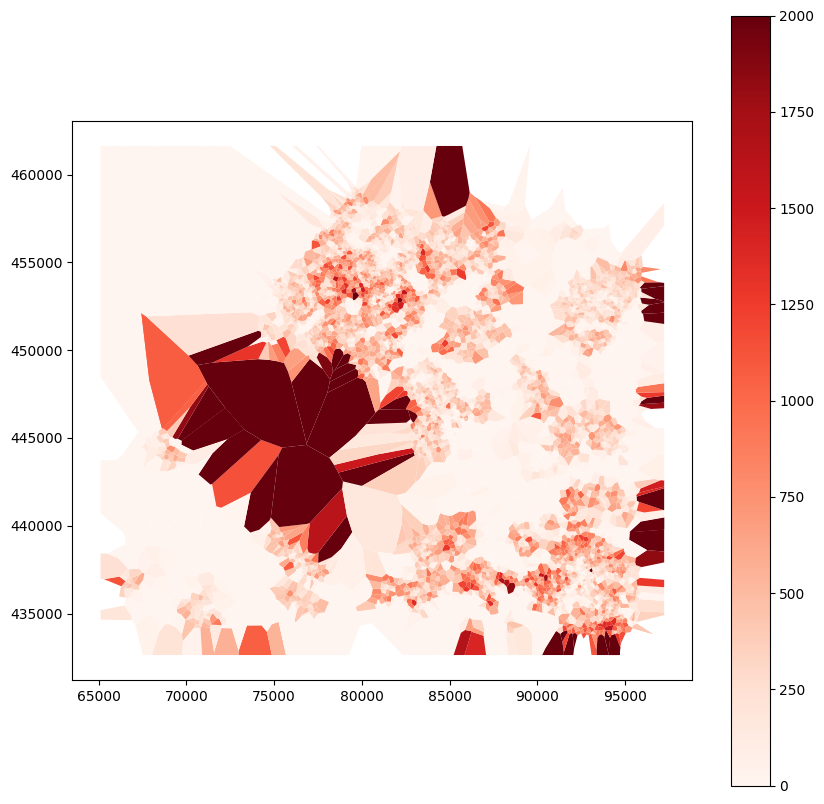

In [24]:

voronoi_gdf = create_voronoi_for_asset_type(gdf_assets, asset_type='msls', bounding_box=bbox_pop)

voronoi_with_impact = assign_impact_metric_to_voronoi(voronoi_gdf, population_above_0, impact_column='aantal_inwoners')

voronoi_with_impact.plot(column='assigned_impact_metric', cmap='Reds', legend=True, figsize=(10, 10), vmax=2000)

results['msls']['raw_population_by_asset'] = {}
for _,row in voronoi_with_impact.iterrows():
    results['msls']['raw_population_by_asset'][row['asset_id']] = row['assigned_impact_metric']
    

voronoi_path_out = config['output_dir'] / 'voronoi_msls.gpkg'
#r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\misc_data\voronoi_msls.gpkg'

voronoi_with_impact.to_file(voronoi_path_out, driver='GPKG')

# for asset_type in asset_types:
#         print(f"\nProcessing {asset_type.upper()} assets...")
        
#         # Create Voronoi polygons
#         voronoi_gdf = create_voronoi_for_asset_type(gdf_assets, asset_type, bounding_box)
#         if verbose:
#             print(f"  Created {len(voronoi_gdf)} Voronoi polygons")

#         # Assign impact metric to Voronoi polygons
#         voronoi_with_impact = assign_impact_metric_to_voronoi(voronoi_gdf, impact_data, impact_column)
#         if verbose:
#             print(f"  Assigned impact metric to Voronoi polygons")



Creating combined visualization of 2 asset types
  Global max impact metric: 14295.2 people

Combined Asset Summary:
  MSLS Assets: 84 assets, Total Impact: 3034647.7 people-hours
  LS Assets: 108 assets, Total Impact: 5416804.0 people-hours
  Combined Total Impact: 8451451.6 people-hours


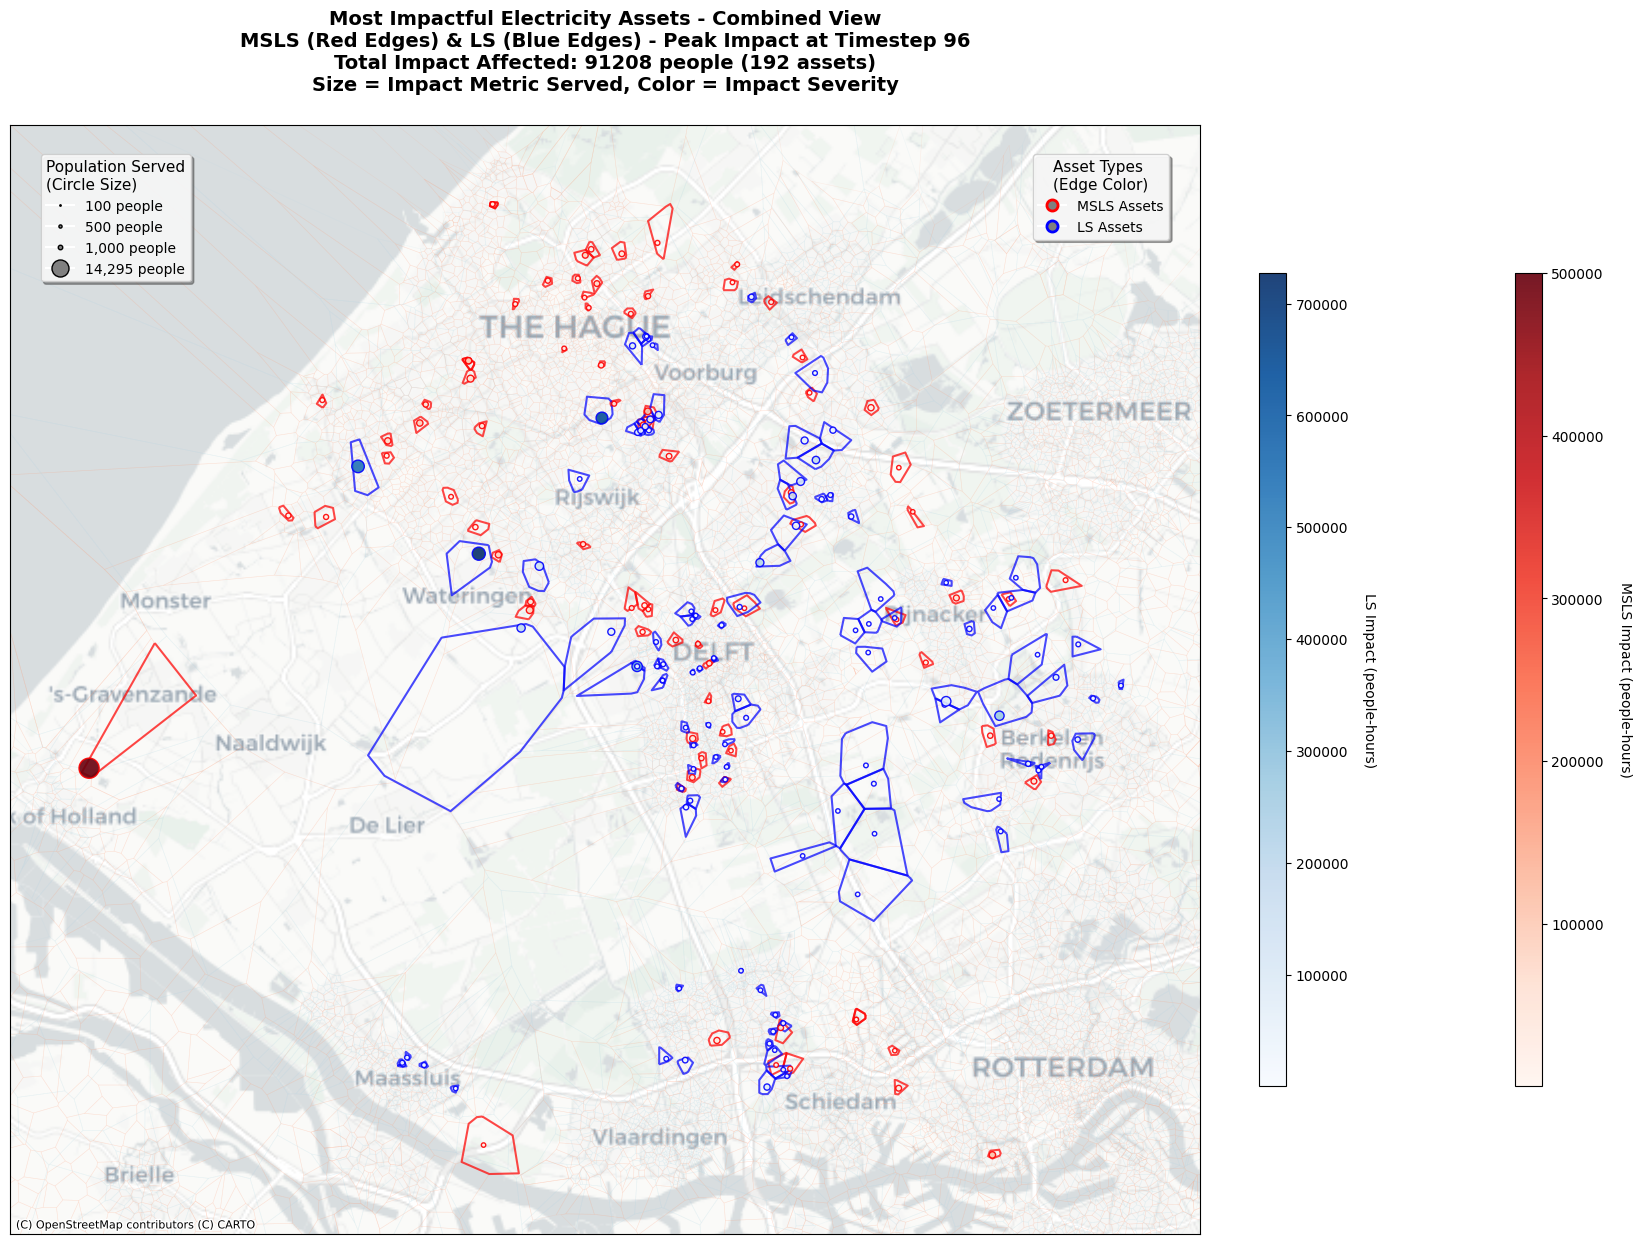

In [35]:

# Use results with the visualization function
datasets_list = list(results.values())
fig, ax = create_combined_type_plot(datasets_list, figsize=(18, 14), tags=False)
plt.show()

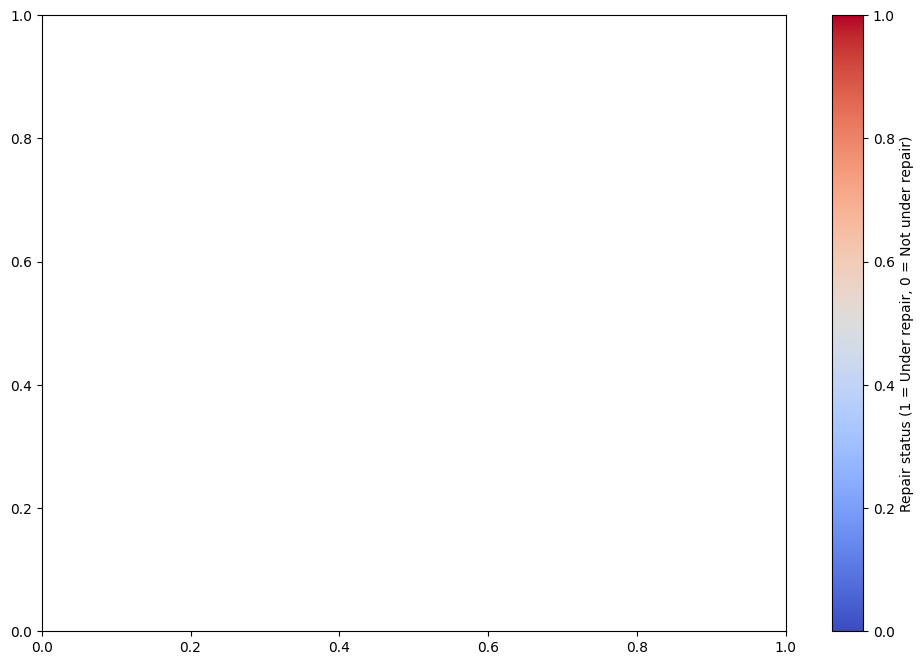

In [26]:
# Create timestep-by-timestep timelapse animation
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Get all unique timesteps
timesteps = sorted(timesteps_df['timestep'].unique())

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Function to animate each frame
def animate(frame):
    ax.clear()
    
    # Get data for current timestep
    current_timestep = timesteps[frame]
    timesteps_df_current = timesteps_df[timesteps_df['timestep'] == current_timestep]
    
    # Create scatter plot
    scatter = ax.scatter(timesteps_df_current['damage_ratio'], 
                        timesteps_df_current['repair_time'], 
                        c=timesteps_df_current['crew_assigned'].astype(int), 
                        cmap='viridis', alpha=0.7, s=50)
    
    # Add labels for assets with non-zero damage ratio
    for idx, row in timesteps_df_current.iterrows():
        if row['damage_ratio'] != 0:
            ax.annotate(int(row['asset_id']), 
                       (row['damage_ratio'], row['repair_time']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=8, alpha=0.8)
    
    # Set labels and title
    ax.set_xlabel('Damage Ratio')
    ax.set_ylabel('Repair Time')
    ax.set_title(f'Asset Damage vs Repair Time - Timestep {current_timestep} (Colored by Operational Status)')
    ax.grid(True, alpha=0.3)
    
    # Set consistent axis limits
    ax.set_xlim(-0.05, timesteps_df['damage_ratio'].max() * 1.1)
    ax.set_ylim(-0.5, timesteps_df['repair_time'].max() * 1.1)
    
    return scatter,

# Create animation
anim = animation.FuncAnimation(fig, animate, frames=len(timesteps), 
                              interval=1000, blit=False, repeat=True)

# Add colorbar (create it once outside the animation)
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='coolwarm'), ax=ax)
cbar.set_label('Repair status (1 = Under repair, 0 = Not under repair)')

plt.show()

# Save the animation
anim.save(config['output_dir'] / 'damage_repair_timelapse.gif', writer='pillow', fps=5)